## Question 2 A and B

In [420]:
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import random

In [421]:
T = 15

In [422]:
h = {t: random.randint(1,5) for t in range(1, T+1)}  
b = {t: random.randint(1,15) for t in range(1, T+1)}  
d = {t: random.randint(100,550) for t in range(1, T+1)}  
c = {t: random.randint(1,25) for t in range(1, T+1)}  
q = {t: 500 for t in range(1, T+1)}  
print(h)
print(b)   
print(c) 
print(d)
print(q)
    

{1: 1, 2: 3, 3: 3, 4: 5, 5: 3, 6: 4, 7: 2, 8: 4, 9: 4, 10: 3, 11: 1, 12: 1, 13: 3, 14: 1, 15: 5}
{1: 5, 2: 4, 3: 15, 4: 13, 5: 4, 6: 4, 7: 6, 8: 13, 9: 4, 10: 14, 11: 1, 12: 12, 13: 11, 14: 15, 15: 5}
{1: 20, 2: 19, 3: 2, 4: 19, 5: 14, 6: 10, 7: 12, 8: 4, 9: 23, 10: 19, 11: 13, 12: 8, 13: 6, 14: 17, 15: 5}
{1: 164, 2: 449, 3: 358, 4: 447, 5: 302, 6: 150, 7: 239, 8: 466, 9: 259, 10: 487, 11: 417, 12: 169, 13: 237, 14: 153, 15: 205}
{1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500, 10: 500, 11: 500, 12: 500, 13: 500, 14: 500, 15: 500}


In [423]:
model = gp.Model("Backpack Inventory Management")

x = model.addVars(range(1,T+1), lb=0, name="x")  
y_plus = model.addVars(range(0,T+1), lb=0, name="y_plus")  
y_minus = model.addVars(range(0,T+1), lb=0, name="y_minus")

model.setObjective(
    gp.quicksum(c[t]*x[t]+h[t]*y_plus[t]+b[t]*y_minus[t] for t in range(1,T+1)),
    GRB.MINIMIZE
)

for t in range(1,T+1):
    model.addConstr(y_plus[t]-y_minus[t]== y_plus[t-1]-y_minus[t-1]+x[t]-d[t])

for t in range(1, T+1):
    model.addConstr(x[t] <= q[t])

for t in range(1, T+1):
    model.addConstr(x[t]>=0)

for t in range(1, T+1):
    model.addConstr(y_plus[t]>=0)

for t in range(1, T+1):
    model.addConstr(y_minus[t]>=0)

    
model.addConstr(y_plus[0]-y_minus[0]==0)


model.optimize()

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (22631.2))

CPU model: Intel(R) Core(TM) Ultra 9 185H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 76 rows, 47 columns and 137 nonzeros
Model fingerprint: 0xc7cda404
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+02, 5e+02]
Presolve removed 61 rows and 3 columns
Presolve time: 0.00s
Presolved: 15 rows, 44 columns, 72 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   7.421250e+02   0.000000e+00      0s
      23    5.2340000e+04   0.000000e+00   0.000000e+00      0s

Solved in 23 iterations and 0.01 seconds (0.00 work units)
Optimal objective  5.234000000e+04


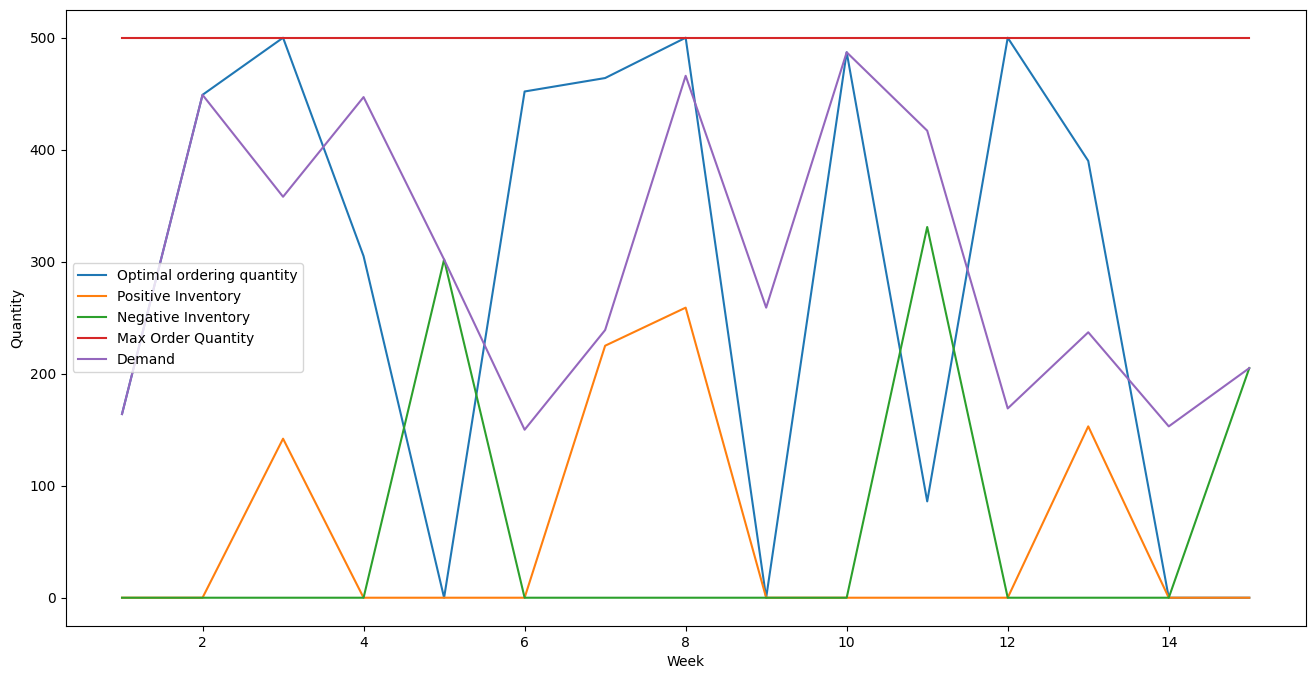

In [424]:
if model.status == GRB.OPTIMAL:
    plt.figure(figsize=(16, 8))
    plt.plot(range(1,T+1), [x[t].X for t in range(1,T+1)], label="Optimal ordering quantity")
    plt.plot(range(1,T+1), [y_plus[t].X for t in range(1,T+1)], label="Positive Inventory")
    plt.plot(range(1,T+1), [y_minus[t].X for t in range(1,T+1)], label="Negative Inventory")
    plt.plot(range(1,T+1), [q[t] for t in range(1,T+1)], label="Max Order Quantity")
    plt.plot(range(1,T+1), [d[t] for t in range(1,T+1)], label="Demand")
    plt.legend()
    plt.xlabel("Week")
    plt.ylabel("Quantity")
else:
    print("No optimal solution found")

In [425]:
for v in model.getVars():
    print(f"{v.varName}: {v.x}")

x[1]: 164.0
x[2]: 449.0
x[3]: 500.0
x[4]: 305.0
x[5]: 0.0
x[6]: 452.0
x[7]: 464.0
x[8]: 500.0
x[9]: 0.0
x[10]: 487.0
x[11]: 86.0
x[12]: 500.0
x[13]: 390.0
x[14]: 0.0
x[15]: 0.0
y_plus[0]: 0.0
y_plus[1]: 0.0
y_plus[2]: 0.0
y_plus[3]: 142.0
y_plus[4]: 0.0
y_plus[5]: 0.0
y_plus[6]: 0.0
y_plus[7]: 225.0
y_plus[8]: 259.0
y_plus[9]: 0.0
y_plus[10]: 0.0
y_plus[11]: 0.0
y_plus[12]: 0.0
y_plus[13]: 153.0
y_plus[14]: 0.0
y_plus[15]: 0.0
y_minus[0]: 0.0
y_minus[1]: 0.0
y_minus[2]: 0.0
y_minus[3]: 0.0
y_minus[4]: 0.0
y_minus[5]: 302.0
y_minus[6]: 0.0
y_minus[7]: 0.0
y_minus[8]: 0.0
y_minus[9]: 0.0
y_minus[10]: 0.0
y_minus[11]: 331.0
y_minus[12]: 0.0
y_minus[13]: 0.0
y_minus[14]: 0.0
y_minus[15]: 205.0


## Question 2 C

case A

In [438]:
h = {t: random.randint(1,5) for t in range(1, T+1)}  
b = {t: random.randint(1,15) for t in range(1, T+1)}  
d = {t: 500 for t in range(1, T+1)}  
c = {t: random.randint(1,25) for t in range(1, T+1)}  
q = {t: 500 for t in range(1, T+1)}  
print(h)
print(b)   
print(c) 
print(d)
print(q)
    

{1: 4, 2: 1, 3: 3, 4: 2, 5: 1, 6: 5, 7: 4, 8: 4, 9: 3, 10: 5, 11: 4, 12: 1, 13: 4, 14: 5, 15: 2}
{1: 12, 2: 7, 3: 8, 4: 10, 5: 11, 6: 5, 7: 15, 8: 7, 9: 2, 10: 9, 11: 1, 12: 12, 13: 6, 14: 2, 15: 9}
{1: 5, 2: 20, 3: 11, 4: 25, 5: 21, 6: 12, 7: 16, 8: 4, 9: 2, 10: 24, 11: 5, 12: 16, 13: 19, 14: 14, 15: 16}
{1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500, 10: 500, 11: 500, 12: 500, 13: 500, 14: 500, 15: 500}
{1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500, 10: 500, 11: 500, 12: 500, 13: 500, 14: 500, 15: 500}


In [439]:
model = gp.Model("Backpack Inventory Management")

x = model.addVars(range(1,T+1), lb=0, name="x")  
y_plus = model.addVars(range(0,T+1), lb=0, name="y_plus")  
y_minus = model.addVars(range(0,T+1), lb=0, name="y_minus")

model.setObjective(
    gp.quicksum(c[t]*x[t]+h[t]*y_plus[t]+b[t]*y_minus[t] for t in range(1,T+1)),
    GRB.MINIMIZE
)

for t in range(1,T+1):
    model.addConstr(y_plus[t]-y_minus[t]== y_plus[t-1]-y_minus[t-1]+x[t]-d[t])

for t in range(1, T+1):
    model.addConstr(x[t] >= q[t])

for t in range(1, T+1):
    model.addConstr(x[t]>=0)

for t in range(1, T+1):
    model.addConstr(y_plus[t]>=0)

for t in range(1, T+1):
    model.addConstr(y_minus[t]>=0)

    
model.addConstr(y_plus[0]-y_minus[0]==0)


model.optimize()

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (22631.2))

CPU model: Intel(R) Core(TM) Ultra 9 185H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 76 rows, 47 columns and 137 nonzeros
Model fingerprint: 0xdc53c959
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 3e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e+02, 5e+02]
Presolve removed 76 rows and 47 columns
Presolve time: 0.00s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.0500000e+05   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.050000000e+05


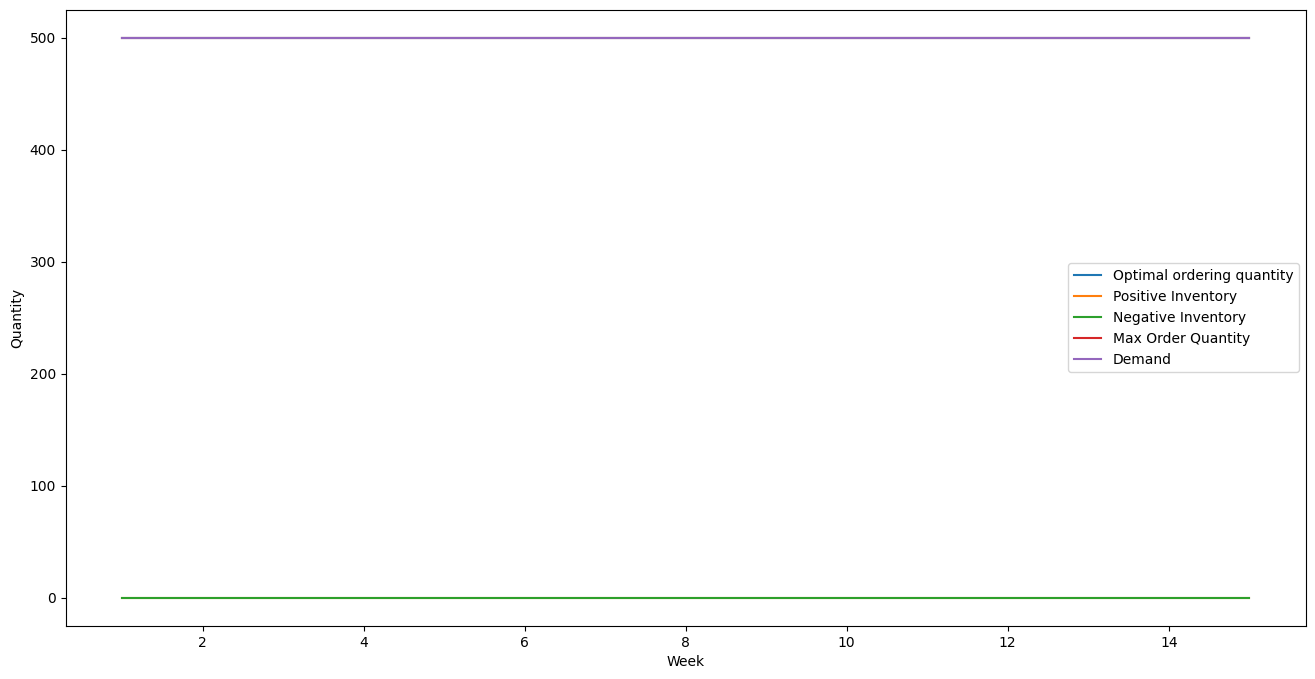

In [440]:
if model.status == GRB.OPTIMAL:
    plt.figure(figsize=(16, 8))
    plt.plot(range(1,T+1), [x[t].X for t in range(1,T+1)], label="Optimal ordering quantity")
    plt.plot(range(1,T+1), [y_plus[t].X for t in range(1,T+1)], label="Positive Inventory")
    plt.plot(range(1,T+1), [y_minus[t].X for t in range(1,T+1)], label="Negative Inventory")
    plt.plot(range(1,T+1), [q[t] for t in range(1,T+1)], label="Max Order Quantity")
    plt.plot(range(1,T+1), [d[t] for t in range(1,T+1)], label="Demand")
    plt.legend()
    plt.xlabel("Week")
    plt.ylabel("Quantity")
else:
    print("No optimal solution found")

In [441]:
for v in model.getVars():
    print(f"{v.varName}: {v.x}")

x[1]: 500.0
x[2]: 500.0
x[3]: 500.0
x[4]: 500.0
x[5]: 500.0
x[6]: 500.0
x[7]: 500.0
x[8]: 500.0
x[9]: 500.0
x[10]: 500.0
x[11]: 500.0
x[12]: 500.0
x[13]: 500.0
x[14]: 500.0
x[15]: 500.0
y_plus[0]: 0.0
y_plus[1]: 0.0
y_plus[2]: 0.0
y_plus[3]: 0.0
y_plus[4]: 0.0
y_plus[5]: 0.0
y_plus[6]: 0.0
y_plus[7]: 0.0
y_plus[8]: 0.0
y_plus[9]: 0.0
y_plus[10]: 0.0
y_plus[11]: 0.0
y_plus[12]: 0.0
y_plus[13]: 0.0
y_plus[14]: 0.0
y_plus[15]: 0.0
y_minus[0]: 0.0
y_minus[1]: 0.0
y_minus[2]: 0.0
y_minus[3]: 0.0
y_minus[4]: 0.0
y_minus[5]: 0.0
y_minus[6]: 0.0
y_minus[7]: 0.0
y_minus[8]: 0.0
y_minus[9]: 0.0
y_minus[10]: 0.0
y_minus[11]: 0.0
y_minus[12]: 0.0
y_minus[13]: 0.0
y_minus[14]: 0.0
y_minus[15]: 0.0


It is optimal to order 500 units each week because our demand is structured to align with this ideal order quantity and 0<x*=qt

case B

In [442]:
h = {t: random.randint(1,5) for t in range(1, T+1)}  
b = {t: random.randint(1,15) for t in range(1, T+1)}  
d = {t: 0 for t in range(1, T+1)}  
c = {t: random.randint(1,25) for t in range(1, T+1)}  
q = {t: 500 for t in range(1, T+1)}  
print(h)
print(b)   
print(c) 
print(d)
print(q)

{1: 1, 2: 1, 3: 4, 4: 1, 5: 1, 6: 2, 7: 4, 8: 5, 9: 1, 10: 2, 11: 2, 12: 1, 13: 2, 14: 4, 15: 2}
{1: 12, 2: 15, 3: 12, 4: 5, 5: 15, 6: 12, 7: 13, 8: 10, 9: 3, 10: 15, 11: 6, 12: 13, 13: 14, 14: 13, 15: 3}
{1: 10, 2: 23, 3: 21, 4: 19, 5: 24, 6: 7, 7: 24, 8: 4, 9: 14, 10: 10, 11: 6, 12: 25, 13: 23, 14: 19, 15: 11}
{1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0}
{1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500, 10: 500, 11: 500, 12: 500, 13: 500, 14: 500, 15: 500}


In [443]:
model = gp.Model("Backpack Inventory Management")

x = model.addVars(range(1,T+1), lb=0, name="x")  
y_plus = model.addVars(range(0,T+1), lb=0, name="y_plus")  
y_minus = model.addVars(range(0,T+1), lb=0, name="y_minus")

model.setObjective(
    gp.quicksum(c[t]*x[t]+h[t]*y_plus[t]+b[t]*y_minus[t] for t in range(1,T+1)),
    GRB.MINIMIZE
)

for t in range(1,T+1):
    model.addConstr(y_plus[t]-y_minus[t]== y_plus[t-1]-y_minus[t-1]+x[t]-d[t])

for t in range(1, T+1):
    model.addConstr(x[t] <= q[t])

for t in range(1, T+1):
    model.addConstr(x[t]>=0)

for t in range(1, T+1):
    model.addConstr(y_plus[t]>=0)

for t in range(1, T+1):
    model.addConstr(y_minus[t]>=0)

    
model.addConstr(y_plus[0]-y_minus[0]==0)


model.optimize()

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (22631.2))

CPU model: Intel(R) Core(TM) Ultra 9 185H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 76 rows, 47 columns and 137 nonzeros
Model fingerprint: 0x3e794653
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 3e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e+02, 5e+02]
Presolve removed 76 rows and 47 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.01 seconds (0.00 work units)
Optimal objective  0.000000000e+00


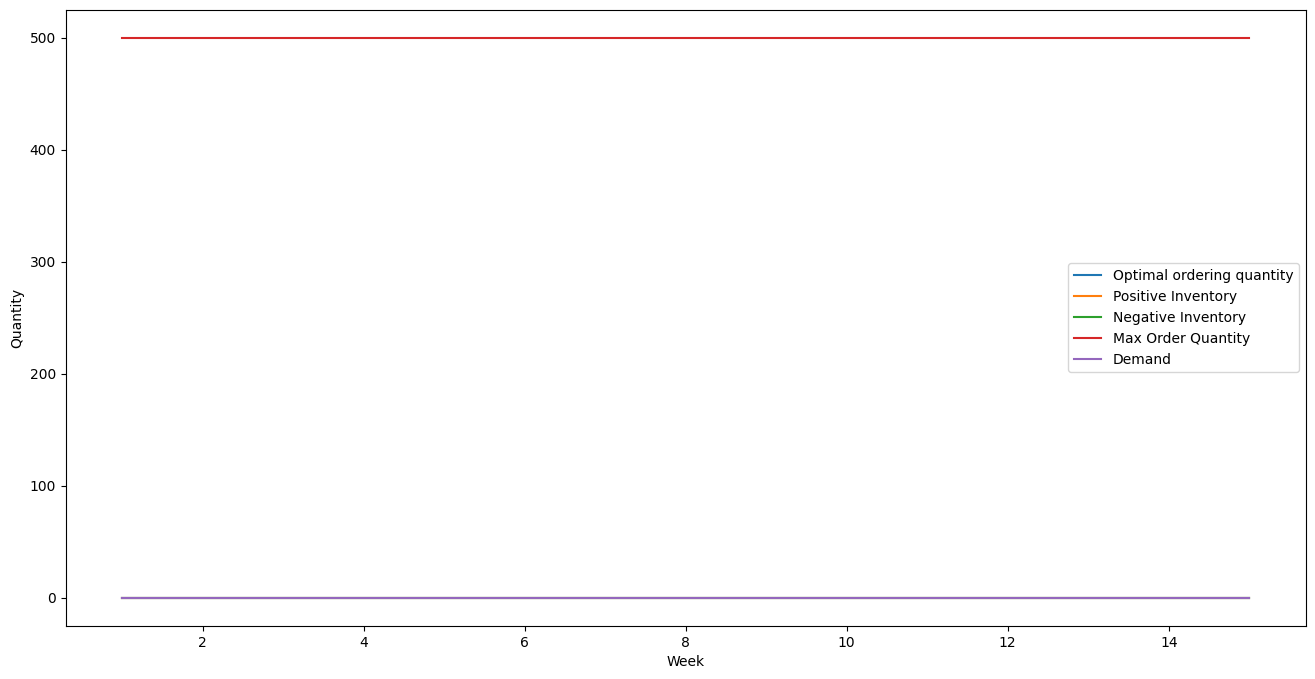

In [444]:
if model.status == GRB.OPTIMAL:
    plt.figure(figsize=(16, 8))
    plt.plot(range(1,T+1), [x[t].X for t in range(1,T+1)], label="Optimal ordering quantity")
    plt.plot(range(1,T+1), [y_plus[t].X for t in range(1,T+1)], label="Positive Inventory")
    plt.plot(range(1,T+1), [y_minus[t].X for t in range(1,T+1)], label="Negative Inventory")
    plt.plot(range(1,T+1), [q[t] for t in range(1,T+1)], label="Max Order Quantity")
    plt.plot(range(1,T+1), [d[t] for t in range(1,T+1)], label="Demand")
    plt.legend()
    plt.xlabel("Week")
    plt.ylabel("Quantity")
else:
    print("No optimal solution found")

In [445]:
for v in model.getVars():
    print(f"{v.varName}: {v.x}")

x[1]: 0.0
x[2]: 0.0
x[3]: 0.0
x[4]: 0.0
x[5]: 0.0
x[6]: 0.0
x[7]: 0.0
x[8]: 0.0
x[9]: 0.0
x[10]: 0.0
x[11]: 0.0
x[12]: 0.0
x[13]: 0.0
x[14]: 0.0
x[15]: 0.0
y_plus[0]: 0.0
y_plus[1]: 0.0
y_plus[2]: 0.0
y_plus[3]: 0.0
y_plus[4]: 0.0
y_plus[5]: 0.0
y_plus[6]: 0.0
y_plus[7]: 0.0
y_plus[8]: 0.0
y_plus[9]: 0.0
y_plus[10]: 0.0
y_plus[11]: 0.0
y_plus[12]: 0.0
y_plus[13]: 0.0
y_plus[14]: 0.0
y_plus[15]: 0.0
y_minus[0]: 0.0
y_minus[1]: 0.0
y_minus[2]: 0.0
y_minus[3]: 0.0
y_minus[4]: 0.0
y_minus[5]: 0.0
y_minus[6]: 0.0
y_minus[7]: 0.0
y_minus[8]: 0.0
y_minus[9]: 0.0
y_minus[10]: 0.0
y_minus[11]: 0.0
y_minus[12]: 0.0
y_minus[13]: 0.0
y_minus[14]: 0.0
y_minus[15]: 0.0


That is the case because our optimal amount to order is always below max amount to order and 0 = x*< qt

case C

In [446]:
h = {t: random.randint(1,5) for t in range(1, T+1)}  
b = {t: random.randint(1,15) for t in range(1, T+1)}  
d = {t: random.randint(600,750) for t in range(1, T+1)}  
c = {t: random.randint(1,25) for t in range(1, T+1)}  
q = {t: 500 for t in range(1, T+1)}  
print(h)
print(b)   
print(c) 
print(d)
print(q)

{1: 1, 2: 4, 3: 5, 4: 5, 5: 1, 6: 2, 7: 4, 8: 2, 9: 2, 10: 3, 11: 1, 12: 5, 13: 4, 14: 1, 15: 4}
{1: 4, 2: 5, 3: 2, 4: 2, 5: 13, 6: 7, 7: 13, 8: 2, 9: 9, 10: 14, 11: 14, 12: 14, 13: 1, 14: 6, 15: 3}
{1: 20, 2: 8, 3: 15, 4: 18, 5: 14, 6: 12, 7: 20, 8: 10, 9: 17, 10: 9, 11: 11, 12: 19, 13: 7, 14: 6, 15: 19}
{1: 649, 2: 736, 3: 689, 4: 620, 5: 603, 6: 613, 7: 665, 8: 720, 9: 611, 10: 613, 11: 646, 12: 745, 13: 629, 14: 642, 15: 668}
{1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500, 10: 500, 11: 500, 12: 500, 13: 500, 14: 500, 15: 500}


In [447]:
model = gp.Model("Backpack Inventory Management")

x = model.addVars(range(1,T+1), lb=0, name="x")  
y_plus = model.addVars(range(0,T+1), lb=0, name="y_plus")  
y_minus = model.addVars(range(0,T+1), lb=0, name="y_minus")

model.setObjective(
    gp.quicksum(c[t]*x[t]+h[t]*y_plus[t]+b[t]*y_minus[t] for t in range(1,T+1)),
    GRB.MINIMIZE
)

for t in range(1,T+1):
    model.addConstr(y_plus[t]-y_minus[t]== y_plus[t-1]-y_minus[t-1]+x[t]-d[t])

for t in range(1, T+1):
    model.addConstr(x[t] <= q[t])

for t in range(1, T+1):
    model.addConstr(x[t]>=0)

for t in range(1, T+1):
    model.addConstr(y_plus[t]>=0)

for t in range(1, T+1):
    model.addConstr(y_minus[t]>=0)

    
model.addConstr(y_plus[0]-y_minus[0]==0)


model.optimize()

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (22631.2))

CPU model: Intel(R) Core(TM) Ultra 9 185H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 76 rows, 47 columns and 137 nonzeros
Model fingerprint: 0x1f39860d
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e+02, 7e+02]
Presolve removed 76 rows and 47 columns
Presolve time: 0.00s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.3899500e+05   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.01 seconds (0.00 work units)
Optimal objective  2.389950000e+05


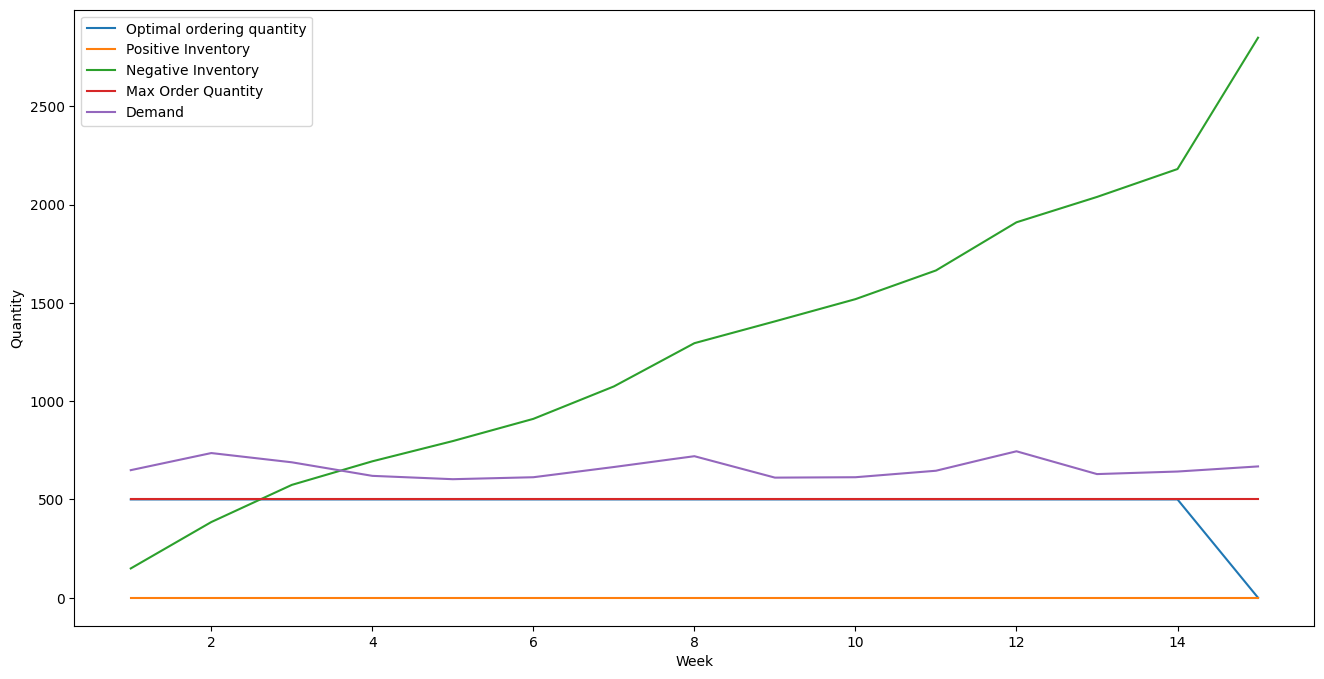

In [448]:
if model.status == GRB.OPTIMAL:
    plt.figure(figsize=(16, 8))
    plt.plot(range(1,T+1), [x[t].X for t in range(1,T+1)], label="Optimal ordering quantity")
    plt.plot(range(1,T+1), [y_plus[t].X for t in range(1,T+1)], label="Positive Inventory")
    plt.plot(range(1,T+1), [y_minus[t].X for t in range(1,T+1)], label="Negative Inventory")
    plt.plot(range(1,T+1), [q[t] for t in range(1,T+1)], label="Max Order Quantity")
    plt.plot(range(1,T+1), [d[t] for t in range(1,T+1)], label="Demand")
    plt.legend()
    plt.xlabel("Week")
    plt.ylabel("Quantity")
else:
    print("No optimal solution found")

In [449]:
for v in model.getVars():
    print(f"{v.varName}: {v.x}")

x[1]: 500.0
x[2]: 500.0
x[3]: 500.0
x[4]: 500.0
x[5]: 500.0
x[6]: 500.0
x[7]: 500.0
x[8]: 500.0
x[9]: 500.0
x[10]: 500.0
x[11]: 500.0
x[12]: 500.0
x[13]: 500.0
x[14]: 500.0
x[15]: 0.0
y_plus[0]: 0.0
y_plus[1]: 0.0
y_plus[2]: 0.0
y_plus[3]: 0.0
y_plus[4]: 0.0
y_plus[5]: 0.0
y_plus[6]: 0.0
y_plus[7]: 0.0
y_plus[8]: 0.0
y_plus[9]: 0.0
y_plus[10]: 0.0
y_plus[11]: 0.0
y_plus[12]: 0.0
y_plus[13]: 0.0
y_plus[14]: 0.0
y_plus[15]: 0.0
y_minus[0]: 0.0
y_minus[1]: 149.0
y_minus[2]: 385.0
y_minus[3]: 574.0
y_minus[4]: 694.0
y_minus[5]: 797.0
y_minus[6]: 910.0
y_minus[7]: 1075.0
y_minus[8]: 1295.0
y_minus[9]: 1406.0
y_minus[10]: 1519.0
y_minus[11]: 1665.0
y_minus[12]: 1910.0
y_minus[13]: 2039.0
y_minus[14]: 2181.0
y_minus[15]: 2849.0


That's the case because ordering the full amount 𝑞𝑡 each period would create excessive surplus inventory (and the costs associated with holding it), while ordering nothing would risk unmet demand (and any penalty or lost-sales cost). Consequently, the model balances these two extremes by choosing an order quantity 𝑥𝑡∗ strictly between 0 and 𝑞𝑡. This “in-between” quantity minimizes the total cost (or maximizes profit) because it precisely meets projected demand requirements while avoiding unnecessary overstock or shortages. backorder cost is growing becuse demand is higher than xt*<qt